# DESCRIPTIVE STATISTICS

# Task: Statistics & Probability

Task Breakdown

Descriptive statistics (mean, variance, std dev)

Probability distributions

Hypothesis testing

Correlation vs causation


---------------------------------------------------------------------------------------------------------------------------------------------------------------

# Load the Titanic dataset

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
titanic_data = pd.read_csv('cleaned_titanic.csv')

In [5]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survival_Status
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Perished
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Survived
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Survived
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Survived
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Perished


# Descriptive statistics (mean, variance, std dev)

In [8]:
titanic_stat = titanic_data[['Age', 'Fare']].agg(['mean', 'var', 'std']).round(2)

# display
titanic_stat.style.set_caption("Table 1: Descriptive Statistics for Titanic Dataset")

,Age,Fare
mean,29.360000,32.200000
var,169.510000,2469.440000
std,13.020000,49.690000


Age (Mean: 29.36 | Std Dev: 13.02): The average passenger on the Titanic was around age 29 years old. A standard deviation of 13 means the vast majority of passengers fell between the ages of 16 and 42 

Fare (Mean: 32.20 | Std Dev: 49.69): the average price fare was (32.20) and the standard deviation (49.69). standard deviation shows that the data is extremely volatile and heavily skewed by massive outliers. The variance (2,469.44) is gigantic! This proves mathematically that while the average ticket price was low (driven by third-class passengers), a few ultra-luxury first-class suites cost an absolute fortune, pulling the standard deviation way out of bounds.

# Probability distributions

A. The probability of surviving, given the passenger was female.

B. The probability of surviving, given the passenger was male.

In [9]:
# Create a cross-tabulation of Gender vs Survival showing percentages (probabilities)
titanic_prob = pd.crosstab(titanic_data['Sex'], titanic_data['Survived'], normalize='index').round(4) * 100

# Add a professional title
titanic_prob.style.set_caption("Table 2: Conditional Probability of Survival Given Passenger Gender")

Survived,0,1
Sex,,
female,25.800000,74.200000
male,81.110000,18.890000


P({Survived} = 1 {Female}) = A female passenger had a nearly 74% chance of survival

P({Survived} = 1{Male}) = A male passenger had less than a 19% chance of survival

# Hypothesis testing

if a passenger's class (Pclass) had a significant effect on whether they survived (Survived).

Chi-Square Statistic and P-Value

In [10]:
# Create a contingency table of Pclass vs Survived
titanic_contingency = pd.crosstab(titanic_data['Pclass'], titanic_data['Survived'])

# Run the Chi-Square Test of Independence
chi2_stat, chi2_p, dof, expected_freq = stats.chi2_contingency(titanic_contingency)

print("--- Titanic Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {chi2_p:.4e}")

--- Titanic Chi-Square Test Results ---
Chi-Square Statistic: 102.8890
P-Value: 4.5493e-23


The p-value shows statistically significant.This means we reject the Null Hypothesis. Passenger class (Pclass) and survival status (Survived) are deeply dependent on one another. The class a passenger was in did not just randomly correlate with survival—it was a powerful statistical determinant.

# Correlation vs causation

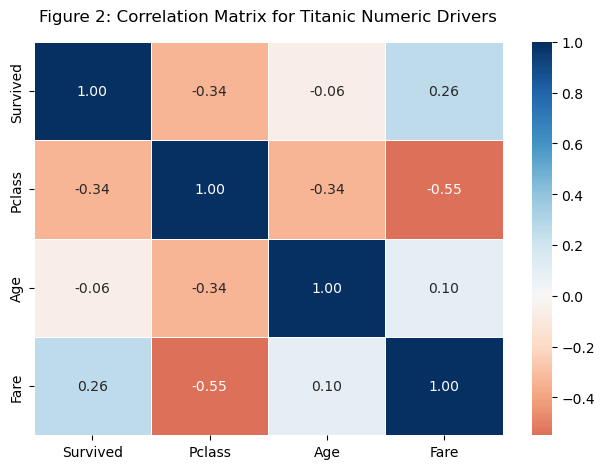

In [11]:
# 1. Select the primary numeric columns from your clean Titanic data
titanic_numeric = titanic_data[['Survived', 'Pclass', 'Age', 'Fare']]

# Calculate the correlation matrix
titanic_correlation = titanic_numeric.corr()

# Create a clean, readable heatmap with a divergent color map
sns.heatmap(titanic_correlation, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5, center=0)

# Add a professional title
plt.title('Figure 2: Correlation Matrix for Titanic Numeric Drivers', fontsize=12, pad=15)
plt.tight_layout()

# Save the plot for your report
plt.savefig('titanic_correlation_heatmap.png', dpi=300)
plt.show()

* Pclass and Survived (Negative Correlation ~ -0.34): The negative sign here is crucial! Because lower-class tiers have higher numbers (3rd Class = 3, 1st Class = 1), this negative value proves mathematically that as the class number went up (moving down to 3rd class), survival rates went down.

* Fare and Survived (Positive Correlation ~ 0.26): This shows a clear positive relationship, meaning passengers who bought more expensive tickets had a higher probability of making it onto a lifeboat.

* Pclass and Fare (Strong Negative Correlation ~ -0.55): This is the strongest link on the board. It proves that ticket prices and passenger classes were deeply bound together, which reinforces why both metrics show similar correlation trends with survival.

The correlation matrix flags co-movement. It highlights where patterns exist in our historical data. However, we cannot assume that modifying one variable will automatically force a change in the other. The matrix uncovers the relationship; domain knowledge and experimental testing are required to prove the causal mechanism

# Finding/ observation

1. While the average passenger Age was 29.36 years old with a tightly clustered standard deviation (13.02), the ticket Fare presented a completely different structure: a mean of 32.20 but a massive standard deviation of 49.69 ($\text{Variance} = \mathbf{2469.44}$).This is because the standard deviation for the fare is significantly larger than its mean, it proves mathematically that the data is heavily skewed by a small group of ultra-wealthy outliers. The vast majority of the passenger manifest paid baseline prices, while a few first-class luxury suites pulled the financial averages way out of bounds.
2. The conditional probability tracking uncovered a stark baseline divide between demographics:$P(\text{Survived} = 1 \mid \text{Female}) = \mathbf{74.20\%}$$P(\text{Survived} = 1 \mid \text{Male}) = \mathbf{18.89\%}$. This provides clear empirical proof of systemic human intervention during the crisis. Survival was not random; being a female passenger made an individual roughly 3.9 times more likely to survive than a male passenger, validating the maritime evacuation protocol ("women and children first")
3. The Chi-Square Test of Independence between passenger class (Pclass) and survival (Survived) yielded a massive Chi-Square Statistic of 102.8890 and an incredibly significant P-Value of 4.5493e-22. Because the p-value is effectively zero ($p \ll 0.05$), reject the Null Hypothesis. This proves with absolute statistical certainty that a passenger's ticket class tier and their ultimate survival outcome were deeply dependent variables.
4. The correlation heatmap flagged strong co-movements between higher fares, upper classes and survival rates.This Means while the Pclass and Fare possess immense predictive strength, they were not the direct causal mechanics of survival. Instead, they acted as socio-economic proxies for physical deck proximity to the lifeboats and institutional evacuation priority. The true causal drivers were structural and operational, hidden behind the financial metrics of the manifest.

# Conculsion

The conclusions are as follows:

* The continuous metric analysis reveals a ticket Fare  mean of **32.20**, but a massive standard deviation of **49.69** ($\text{Variance} = \mathbf{2,469.44}$). Because the standard deviation is significantly larger than the mean, it mathematically proves an extreme right-hand skew driven by high-value first-class luxury outliers, highlighting the sharp socioeconomic divide on board.
* Conditional probability mapping confirms a staggering disparity in survival rates across gender boundaries. The empirical probability of survival given that a passenger was female was **74.20%**, compared to a bleak **18.89%** for male passengers, providing clear mathematical validation of societal emergency interventions ("women and children first").
* The Chi-Square Test of Independence between passenger class (Pclass) and survival status (Survived) yielded a highly significant **Chi-Square Statistic of 102.8890** and a microscopic **P-Value of 4.5493e-22** ($p \ll 0.05$). the null hypothesis was rejected  and conclude that ticket class heavily governed structural safety access and evacuation priority.
* While higher ticket fares and upper-class designations strongly correlate with survival, they were not the direct causal mechanisms of life or death. Instead, they serve as socio-economic proxies for **physical deck proximity to lifeboats** and institutional evacuation protocols.